In [1]:
import pzflow
import optax
from pzflow import Flow
import jax
import jax.numpy as jnp
from pzflow.bijectors import Chain, ShiftBounds, RollingSplineCoupling
from pzflow.distributions import Uniform, CentBeta13
from sklearn.neighbors import KernelDensity

import os
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

import torch

from astropy.io import fits
from astropy.table import Table

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KernelDensity

import optax

In [2]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', device)
print()

#Additional Info when using cuda
if device.type == 'cuda':
    print(torch.cuda.get_device_name(0))
print(torch.cuda.get_device_properties(device)) 

Using device: cuda

NVIDIA A100-PCIE-40GB
_CudaDeviceProperties(name='NVIDIA A100-PCIE-40GB', major=8, minor=0, total_memory=40326MB, multi_processor_count=108, uuid=a0a426b9-74ff-48c5-9d0a-f1b6ff09c18d, L2_cache_size=40MB)


## Setting up Data for Cathode
#### 1. First separate data into signal and non-signal using pm_ra (I call Phi1 and Phi2 coordiantes RA and DEC). Note we train on entire complement of SR, not just SB.
#### 2. Train flow on non-signal data, condition on pm_ra
#### 3. Fit KDE to pm_ra distribution in the signal region
#### 4. Sample N values from $p_{KDE}$(pm_ra)
#### 5. Generate N samples from flow conditioned on the N sampled pm_ra values

### Load in the data being used, set up scaler

In [3]:
load_data_dir = '/pscratch/sd/p/pratsosa/C-19_gaia_x_decals_stream_prep.fits'
df = Table.read(load_data_dir)

ra = np.array(df['phi1']).astype('float64')
dec = np.array(df['phi2']).astype('float64')

pm_ra  = np.array(df['pm_phi1']).astype('float64')
pm_dec = np.array(df['pm_phi2']).astype('float64')

pm_ra_error = np.array(df['pmra_error']).astype('float64')
pm_dec_error = np.array(df['pmdec_error']).astype('float64')

gmag  = np.array(df['phot_g_mean_mag'])
color = np.array(df['phot_bp_mean_mag']) - np.array(df['phot_rp_mean_mag'])
parallax = np.array(df['parallax'])
parallax_error = np.array(df['parallax_error'])

gmag0, rmag0, zmag0 = np.array(df['gmag0']), np.array(df['rmag0']), np.array(df['zmag0'])
g_r = gmag0-rmag0
r_z = rmag0-zmag0
g_z = gmag0-zmag0

stream = np.array(df['stream'])

signal_region = np.array(df['signal_region'], dtype=bool)

embeddings = np.column_stack((ra, dec, pm_dec, gmag, color, rmag0, g_r, r_z)) # Embeddings exclude pm_ra
full_embeddings = np.column_stack((ra, dec, pm_ra, pm_dec, gmag, color, rmag0, g_r, r_z))  # Full embeddings include pm_ra

# Scale the full_embeddings with standard scaler before passing to the flow
scaler = StandardScaler()
scaler.fit(full_embeddings)
print(f'There are {signal_region.sum()} signal region points and {(~signal_region).sum()} non-signal region points.')
print(f'There are {stream.sum()} stream points.')

There are 115722 signal region points and 1053306 non-signal region points.
There are 43 stream points.


In [6]:
pm = np.sqrt(df['pmra'].data**2 + df['pmdec'].data**2)
pm_ra_t = df['pmra'].data
pm_dec_t = df['pmdec'].data
pm_ra_error = df['pmra_error'].data
pm_dec_error = df['pmdec_error'].data

In [7]:
pm_mask = (np.abs(pm_ra_t - pm_ra_error) < 1) & (np.abs(pm_dec_t - pm_dec_error) < 1) & (np.abs(pm_ra_t + pm_ra_error) < 1) & (np.abs(pm_dec_t + pm_dec_error) < 1)
pm_mask.mean()

np.float64(0.029514263131422)

In [8]:
ra_mask = ra < 15

In [12]:
ra_dec_mask = ((ra > -5) | (dec > -5))

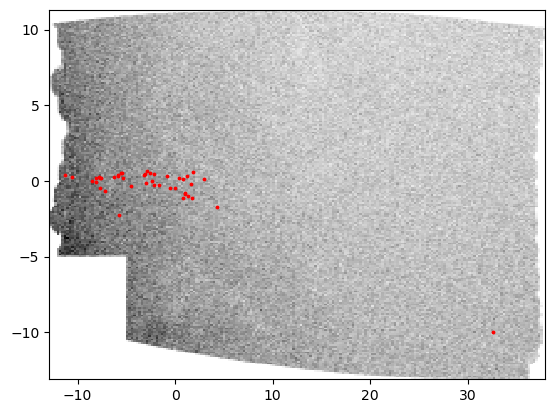

In [13]:
plt.hist2d(ra[ra_dec_mask], dec[ra_dec_mask], bins=200, cmap='grey_r', density=True)
plt.scatter(ra[stream], dec[stream], s=3, color='red')
plt.show()

#### Quasar Removal Experiment

In [51]:
np.sum(stream & ~pm_mask)

np.int64(43)

In [12]:
def quasar_sel_cut(gmag):
    return 10 ** (0.4 * (gmag - 18.25))

Text(0, 0.5, 'Proper Motion (mas/yr)')

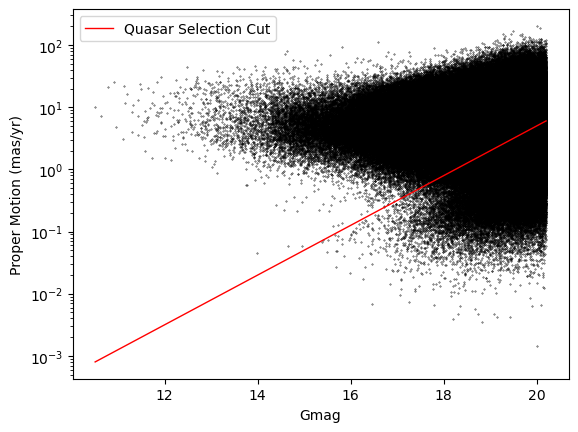

In [14]:
x = np.linspace(gmag.min(), gmag.max(), 1000)
plt.scatter(gmag, pm, s=.1, c='k')
plt.plot(x, quasar_sel_cut(x), c='r', lw=1, label='Quasar Selection Cut')
plt.legend()
plt.yscale('log')
plt.xlabel('Gmag')
plt.ylabel('Proper Motion (mas/yr)')

In [35]:
quasar_mask = pm < quasar_sel_cut(gmag)
np.sum(quasar_mask), np.mean(quasar_mask), (quasar_mask & stream).sum()

(np.int64(213794), np.float64(0.18288184714138583), np.int64(15))

In [28]:
np.mean((pm_ra_t < 1) & (pm_dec_t < 1))

np.float64(0.523359577358284)

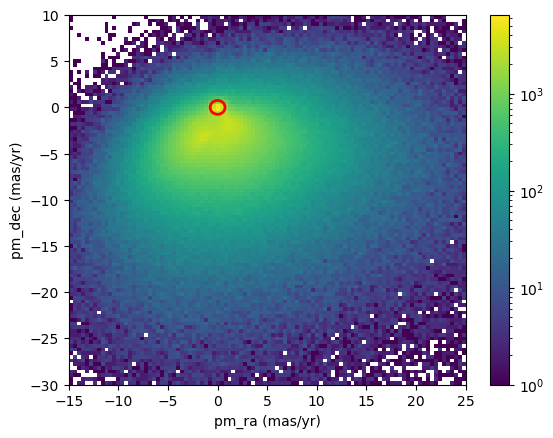

In [40]:
plt.hist2d(pm_ra_t, pm_dec_t, bins=100, range=[[-15,25],[-30,10]], norm=plt.matplotlib.colors.LogNorm())
# Add circle of radius 1 around pm_ra=0, pm_dec=0
circle = plt.Circle((0, 0), .75, color='r', fill=False, lw=2)
plt.gca().add_artist(circle)
plt.xlabel('pm_ra (mas/yr)')
plt.ylabel('pm_dec (mas/yr)')
plt.colorbar()

In [44]:
np.mean((np.abs(pm_ra_t) < 1) & (np.abs(pm_dec_t) < 1))

np.float64(0.04838036385783745)

In [49]:
np.mean((np.abs(pm_ra_t[~pm_mask]) < 1) & (np.abs(pm_dec_t[~pm_mask]) < 1))

np.float64(0.019439853683259515)

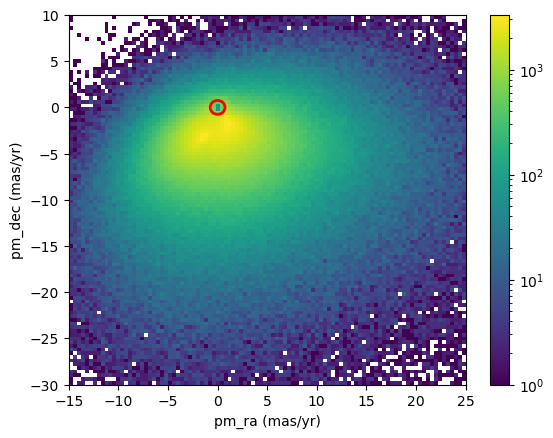

In [47]:
plt.hist2d(pm_ra_t[~pm_mask], pm_dec_t[~pm_mask], bins=100, range=[[-15,25],[-30,10]], norm=plt.matplotlib.colors.LogNorm())
# Add circle of radius 1 around pm_ra=0, pm_dec=0
circle = plt.Circle((0, 0), .75, color='r', fill=False, lw=2)
plt.gca().add_artist(circle)
plt.xlabel('pm_ra (mas/yr)')
plt.ylabel('pm_dec (mas/yr)')
plt.colorbar()

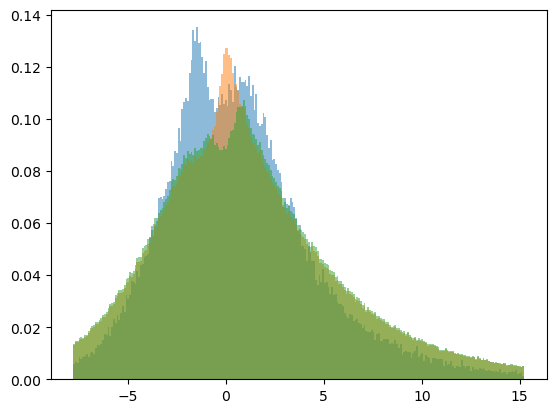

In [58]:
plt.hist(pm_dec[signal_region], density=True, bins=250, alpha =.5, range = (np.percentile(pm_dec[signal_region], 1), np.percentile(pm_dec[signal_region], 99)))
plt.hist(pm_dec[~signal_region], density=True, bins=250, alpha =.5, range = (np.percentile(pm_dec[signal_region], 1), np.percentile(pm_dec[signal_region], 99)))
plt.hist(pm_dec[~signal_region & ~pm_mask], density=True, bins=250, alpha =.5, range = (np.percentile(pm_dec[signal_region], 1), np.percentile(pm_dec[signal_region], 99)))
plt.show()

#### Apply Masks

In [15]:
# These are used by pzflow to identify columns

col_names = ['ra', 'dec', 'pm_ra', 'pm_dec', 'gmag', 'color', 'rmag0', 'g_r', 'r_z']
data_col_names = ['ra', 'dec', 'pm_dec', 'gmag', 'color', 'rmag0', 'g_r', 'r_z']
cond_col_names = ["pm_ra"]

In [16]:
# I want to apply my pm_mask to embeddings, full_embeddings, signal_region, and stream
# Apply ra mask as well
embeddings = embeddings[(~pm_mask & ra_mask & ra_dec_mask)]
full_embeddings = full_embeddings[(~pm_mask & ra_mask & ra_dec_mask)]
signal_region = signal_region[(~pm_mask & ra_mask & ra_dec_mask)]
stream = stream[(~pm_mask & ra_mask & ra_dec_mask)]

In [17]:
# Create a mask which masks the .05th and 99.95th percentiles of the pm_ra, pm_dec, color, rmag0, g_r, r_z, in full_embeddings (everything except ra, dec, gmag which are columns 1, 2, 5)
# Logic is that ra and dec don't have extreme outliers, and a cut on gmag has already been applied in data prep
perc_mask = np.ones(full_embeddings.shape[0], dtype=bool)
perc_low = .05
perc_high = 99.95
for i in range(full_embeddings.shape[1]):
    if i in [0, 1, 4]:  # Skip ra, dec, gmag
        continue
    col = full_embeddings[:, i]
    lower_perc = np.percentile(col, perc_low)
    upper_perc = np.percentile(col, perc_high)
    perc_mask &= (col >= lower_perc) & (col <= upper_perc)

embeddings = embeddings[perc_mask]
full_embeddings = full_embeddings[perc_mask]
signal_region = signal_region[perc_mask]
stream = stream[perc_mask]

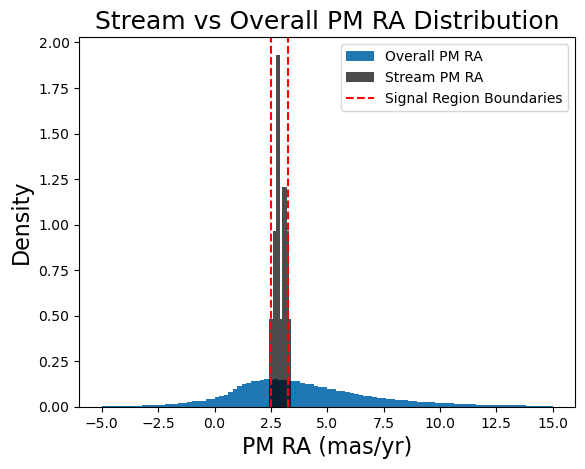

In [18]:
# Shows the stream pm_ra distribution vs overall pm_ra distribution

plt.hist(full_embeddings[:, 2], density=True, bins = 100, range=(-5, 15), label='Overall PM RA')
plt.hist(full_embeddings[stream, 2], density=True, bins=10, color='black', alpha=0.7, label='Stream PM RA')

# Plot the boundaries of the signal region
plt.axvline(x=np.min(full_embeddings[signal_region, 2]), color='r', linestyle='--', label='Signal Region Boundaries')
plt.axvline(x=np.max(full_embeddings[signal_region, 2]), color='r', linestyle='--')
plt.legend()
plt.xlabel('PM RA (mas/yr)', fontsize=16)
plt.ylabel('Density', fontsize=16)
plt.title('Stream vs Overall PM RA Distribution', fontsize=18)
plt.show()

In [19]:
# Put the data in dataframes for flow

full_embeddings = scaler.transform(full_embeddings)
train_data = full_embeddings[~signal_region] # All data not in the signal region is used to train.

train_split, test_split = train_test_split(train_data, test_size=0.2, random_state=12345)

df_train = pd.DataFrame(data=train_split, columns = col_names)
df_train_subsampled = df_train.sample(frac=.1, random_state=12345) # Sometimes I had issues when training on all the data so I used subsampled dataframes
df_test = pd.DataFrame(data=test_split, columns = col_names)
df_test_subsampled = df_test.sample(frac = .1, random_state = 12345) # Same as above

### The following cell is used to define a "custom" flow and not use the default pzflow architecture
#### - Either run this cell or the one following it, which just creates a default flow

In [20]:
data = df_train[data_col_names].values
mins = jnp.array(data.min(axis=0))
maxs = jnp.array(data.max(axis=0))
ndim = data.shape[1]

# Splines are defined on range [-B, B]. I kept the default value of B=5.
B = 5
shift_B = B - 1.0  # map into [-4,4] if B=5 (recommended by pzflow docs)

bijector = Chain(
    ShiftBounds(mins, maxs, B=shift_B), # Does the shifting
    RollingSplineCoupling(nlayers=9,  # nlayers: number of (NeuralSplineCoupling(), Roll()) pairs in the chain - default = ndim
                          hidden_layers = 3, # hidden_layers: number of hidden layers used to parametrize each Spline - default = 2
                          hidden_dim = 128, B=B, # hidden_dim: number of neurons in each hidden layer. B: Same as above - default = 128
                          n_conditions = 1, # n_conditions: leave as 1 since we are conditioning on pm_phi1 only
                          K=16) # K: Spline resolution? Paper states "In the limit of high spline resolution (i.e. K → ∞) [...] [flow] can model  model arbitrarily complex distributions"
                                # default = 16
)

# latent = Uniform(input_dim=ndim, B=6)
latent = CentBeta13(input_dim=ndim, B=B) # The default latent space used by pzflow - centered beta distribution with alpha, beta = 13

flow = Flow(data_col_names, bijector=bijector, latent=latent,
            conditional_columns=cond_col_names)

In [13]:
# Use either this cell or the cell above to instantiate flow
# Instantiate flow with default architecture
flow = Flow(data_columns=data_col_names, conditional_columns=cond_col_names)

In [21]:
# Set up the optimizer parameters. Using cosine one-cycle schedule

num_epochs = 100
max_lr = 1e-3
batch_size = 256
total_steps = len(df_train) // batch_size * num_epochs
pct_start = 0.3
div_factor = 25
final_div_factor = 1000

# Create the one-cycle schedule function
lr_schedule = optax.cosine_onecycle_schedule(
    peak_value=max_lr,
    transition_steps=total_steps,
    pct_start=pct_start,
    div_factor=div_factor,
    final_div_factor=final_div_factor
)

opt = optax.chain(
    optax.clip_by_global_norm(1.0),  # Gradient clipping
    optax.adam(learning_rate=lr_schedule)   # Very low learning rate
)

In [13]:
df_train.shape, df_test.shape

((202683, 9), (810736, 9))

In [22]:
%%time
train_losses, test_losses = [], []
train_losses, test_losses = flow.train(df_train, df_test, 
                                       verbose=True, epochs=num_epochs, 
                                       progress_bar=False, batch_size=batch_size, 
                                       optimizer=opt, patience = 50)

Training 100 epochs 
Loss:
(0) 24.2242  24.1970
(1) 3.5616  3.5703
(6) 2.5032  2.5293
(11) 2.2230  2.2566
(16) 2.0671  2.0923
(21) 1.7074  1.7429
(26) 1.7214  1.7587
(31) 1.5333  1.5794
(36) 1.5866  1.6405
(41) 1.4478  1.5135
(46) 1.4416  1.5052
(51) 1.4780  1.5483
(56) 1.5704  1.6629
(61) 1.1704  1.2881
(66) 1.1605  1.2921
(71) 1.1091  1.2623
(76) 1.0210  1.2013
(81) 1.0064  1.2137
(86) 0.9284  1.1624
(91) 0.8957  1.1493
(96) 0.8778  1.1431
(100) 0.8753  1.1422
CPU times: user 16min 30s, sys: 1min 10s, total: 17min 41s
Wall time: 14min 28s


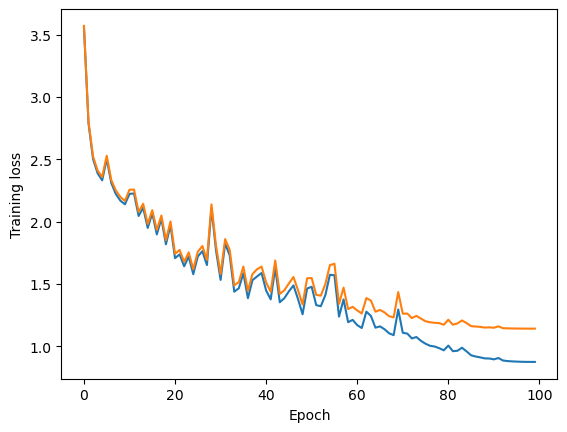

In [23]:
plt.plot(train_losses[1:])
plt.plot(test_losses[1:])
plt.xlabel("Epoch")
plt.ylabel("Training loss")
# plt.ylim(1.55, 3)
plt.show()

In [70]:
flow.save('C19_noerrs_LS_pmcut.pickle')

In [24]:
kde_sig = KernelDensity(bandwidth=0.001)
kde_sig.fit(full_embeddings[:, 2][signal_region].reshape(-1, 1))
m_kde_samples = kde_sig.sample(n_samples= 4 * np.sum(signal_region))  # We sample 4x the number of signal region points as recommended in CATHODE paper

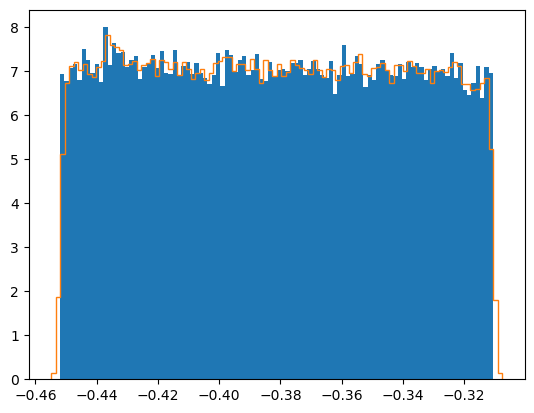

In [25]:
# Quick check that the sampled pm_ra distribution looks similar to the signal region pm_ra distribution

plt.hist(full_embeddings[:, 2][signal_region], bins=100, density=True)
plt.hist(m_kde_samples, bins=100, density=True, histtype='step')
plt.show()

In [26]:
samples_df = flow.sample(nsamples=1, 
                      conditions=pd.DataFrame(data=m_kde_samples.astype('float64'),
                      columns = ["pm_ra"]),
                      save_conditions=True)
# Invert scaling on the samples
samples_df[col_names] = scaler.inverse_transform(samples_df[col_names])
samples_df.head()

,ra,dec,pm_dec,gmag,color,rmag0,g_r,r_z,pm_ra
0,-4.783783,-4.643249,2.854417,19.187984,0.817540,18.961205,0.300131,0.066641,3.252001
1,13.137243,2.664586,-1.519002,19.150509,1.942422,18.904240,1.371039,0.882833,3.134767
2,-9.063531,4.083343,-1.665812,18.553955,0.807154,18.374611,0.355533,0.084747,2.613624
3,12.763761,-7.921001,0.706339,19.385082,0.730454,19.256990,0.244524,0.046300,3.011958
4,4.136151,-4.288108,-3.691109,18.273262,0.972790,18.106598,0.535674,0.231885,3.253880


In [74]:
# Can also sample from the non-signal region similarly in order to check behavior of the flow on training-like data
kde_side = KernelDensity(bandwidth=0.001)
kde_side.fit(full_embeddings[:, 2][~signal_region].reshape(-1, 1))
side_pm_ra_samples = kde_side.sample(n_samples=len(full_embeddings[:, 2][~signal_region]))

# Or uncomment this line to just use the actual pm_ra values from the non-signal region (exact training data)
# side_pm_ra_samples = full_embeddings[:, 2][~signal_region].reshape(-1, 1)

side_samples_df = flow.sample(nsamples=1,
                        conditions=pd.DataFrame(data=side_pm_ra_samples.astype('float64'),
                        columns = ["pm_ra"]),
                        save_conditions=True)
side_samples_df[col_names] = scaler.inverse_transform(side_samples_df[col_names])
side_samples_df.head()

,ra,dec,pm_dec,gmag,color,rmag0,g_r,r_z,pm_ra
0,-7.648484,-5.957278,0.972741,19.013620,1.618885,18.656864,1.149627,0.622839,10.238194
1,-8.347579,-0.293391,-2.576791,19.557846,1.049144,19.178190,0.580002,0.252923,4.514742
2,-1.233795,3.435590,4.993183,18.880230,2.022825,18.648033,1.392551,0.977290,-0.273947
3,-6.245122,2.855182,-4.555504,18.360918,1.427775,18.069675,0.900789,0.462651,5.247594
4,1.202690,-0.316714,4.667342,19.859974,2.244778,19.936272,1.400331,1.401282,6.399937


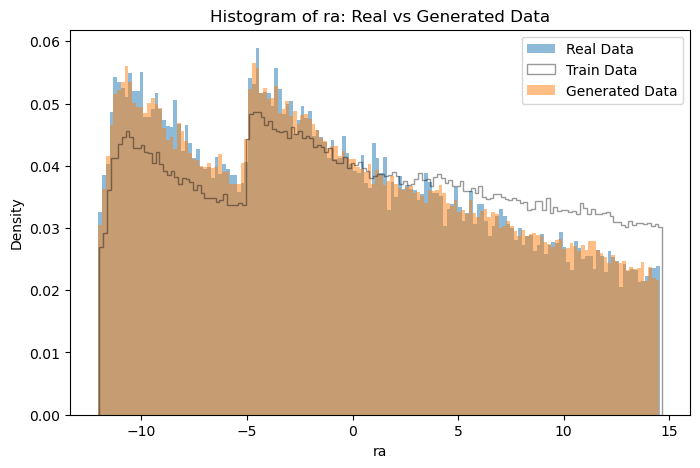

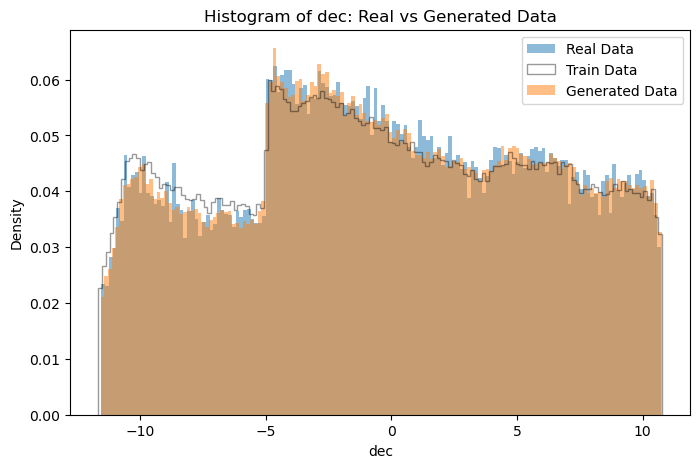

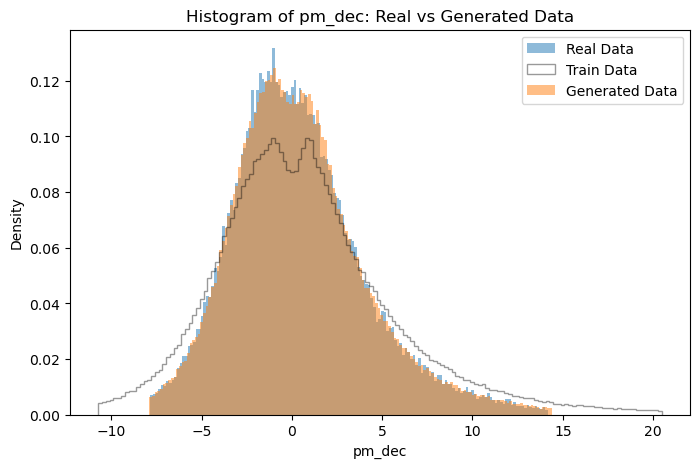

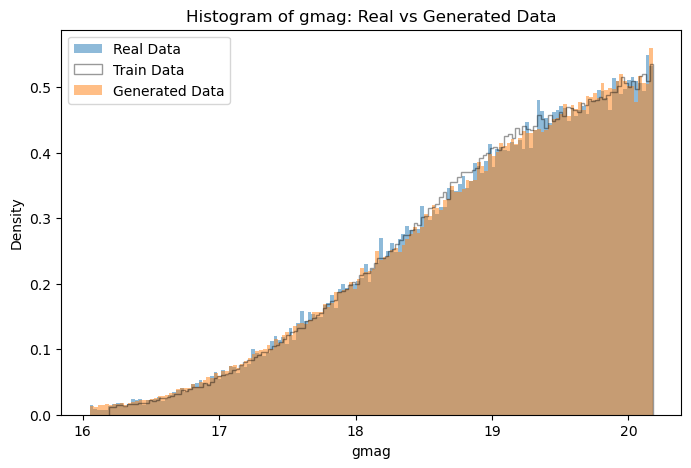

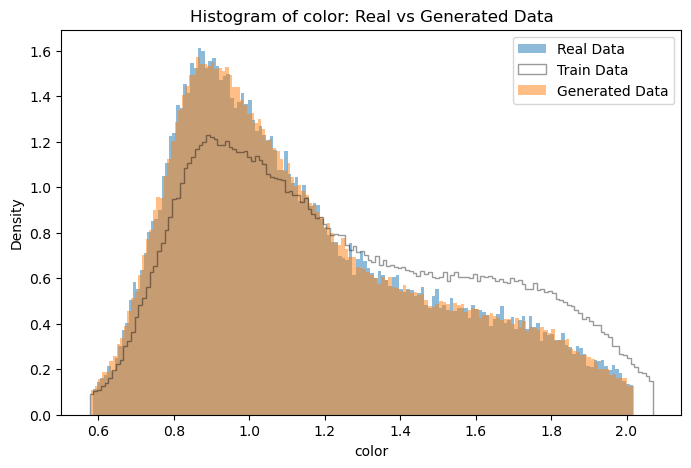

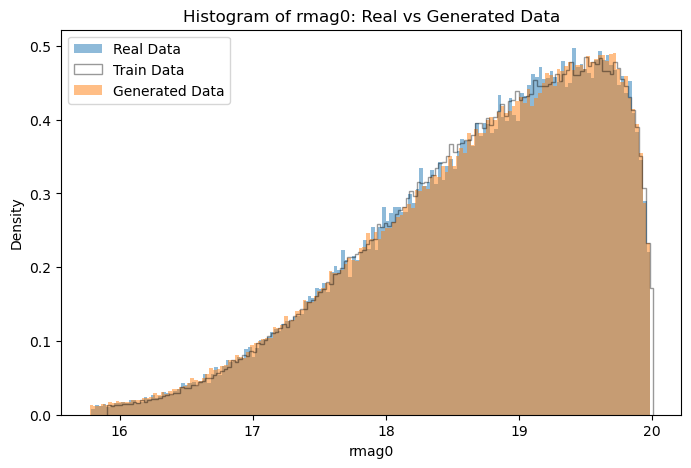

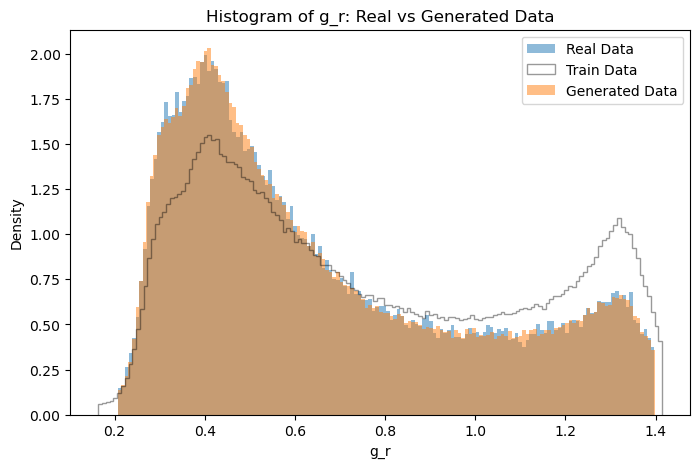

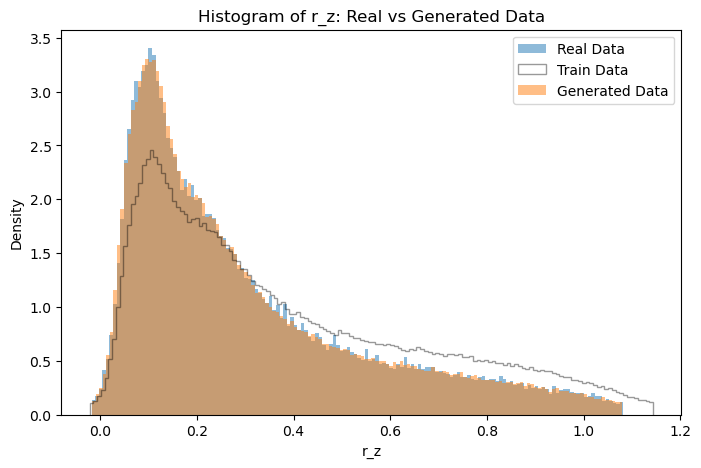

In [27]:
# Print 1D histograms of the generated samples vs the signal region data for each feature
# This shows us how well the flow is interpolating in the signal region
sig_data = embeddings[signal_region]
train_data = embeddings[~signal_region]
sig_generated = samples_df.to_numpy()

for i, col in enumerate(data_col_names):
    plt.figure(figsize=(8,5))
    plt.hist(sig_data[:, i], density=True, bins=150, alpha=0.5, label='Real Data', range=(np.percentile(sig_data[:, i], 1), np.percentile(sig_data[:, i], 99)))
    plt.hist(train_data[:, i], density=True, bins=150, alpha=0.4, label='Train Data', color = 'black', histtype='step',range=(np.percentile(train_data[:, i], 1), np.percentile(train_data[:, i], 99)))
    plt.hist(sig_generated[:, i], density=True, bins=150, alpha=0.5, label='Generated Data', range=(np.percentile(sig_generated[:, i], 1), np.percentile(sig_generated[:, i], 99)))
    plt.xlabel(col)
    plt.ylabel('Density')
    plt.title(f'Histogram of {col}: Real vs Generated Data')
    plt.legend()
    plt.show()

In [ ]:
# Print 1D histograms of the generated samples vs the non-signal data for each feature
# This allows us to visualize how well the flow is doing on training-like data
side_data = embeddings[~signal_region]
side_generated = side_samples_df.to_numpy()

for i, col in enumerate(data_col_names):
    plt.figure(figsize=(8,5))
    plt.hist(side_data[:, i], density=True, bins=100, alpha=0.5, label='Real Data')
    plt.hist(side_generated[:, i], density=True, bins=100, alpha=0.5, label='Generated Data')
    plt.xlabel(col)
    plt.ylabel('Density')
    plt.title(f'Histogram of {col}: Real vs Generated Data')
    plt.legend()
    plt.show()

In [28]:
full_embeddings = scaler.inverse_transform(full_embeddings)
signal_df = pd.DataFrame(data=full_embeddings[signal_region], columns = col_names)

In [29]:
signal_stream = stream[signal_region]
signal_df['stream'] = signal_stream.astype(int)
signal_df['CWoLa_Label'] = np.ones_like(signal_stream).astype(int)

samples_df['stream'] = np.ones(len(samples_df)).astype(int) * 2
samples_df['CWoLa_Label'] = np.zeros(len(samples_df)).astype(int)

In [30]:
full_df = pd.concat([signal_df, samples_df], ignore_index=True)
full_df

,ra,dec,pm_ra,pm_dec,gmag,color,rmag0,g_r,r_z,stream,CWoLa_Label
0,-12.434820,10.391940,2.855079,-0.788379,18.582253,1.217260,18.317919,0.685015,0.323606,0,1
1,-12.501746,10.331434,3.028402,1.436155,14.620204,1.236268,14.356553,0.708346,0.245432,0,1
2,-12.509508,10.359844,2.667051,3.560543,17.812944,1.137426,17.519907,0.669191,0.242048,0,1
3,-3.355297,-10.727945,2.881922,-2.801335,14.747632,1.166240,14.496588,0.682369,0.370433,0,1
4,-3.373788,-10.752620,3.074196,2.318910,18.876352,1.066858,18.627565,0.588554,0.240072,0,1
...,...,...,...,...,...,...,...,...,...,...,...
356015,0.758935,0.556319,2.549440,3.493500,18.590145,0.754535,18.329378,0.305160,0.042404,2,0
356016,7.004079,3.912651,2.574157,4.191761,17.610825,0.931791,17.455687,0.454921,0.200377,2,0
356017,-0.396458,-5.226186,3.153203,6.798964,19.020954,1.331747,18.606516,0.824721,0.407945,2,0
356018,12.916274,4.844772,3.150394,1.576424,20.115961,1.521992,19.914156,1.337154,0.971476,2,0


In [31]:
full_df.to_csv('C19_noerrs_LS_CATHODE_pmcut_radeccut.csv', index=False)

In [ ]:
np.sum(full_df['CWoLa_Label'] == 1)

In [ ]:
full_df.head()